Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Training samples: 50000
Image shape: (32, 32, 3)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 108ms/step - accuracy: 0.4351 - loss: 1.5529 - val_accuracy: 0.5696 - val_loss: 1.2471
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 104ms/step - accuracy: 0.5770 - loss: 1.1906 - val_accuracy: 0.6184 - val_loss: 1.0928
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.6263 - loss: 1.0566 - val_accuracy: 0.6363 - val_loss: 1.0341
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.6619 - loss: 0.9626 - val_accuracy: 0.6700 - val_loss: 0.9469
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 106ms/step - accuracy: 0.6855 - loss: 0.8914 - val_accuracy: 0.6849 - val_loss: 0.9065
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.7074 - loss: 0.8267 - val_accuracy: 0.6982 - val_loss: 0.8732
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 102ms/step - accuracy: 0.7305 - loss: 0.7677 - val_accuracy: 0.6967 - val_loss: 0.8782
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 100ms/step - accuracy: 0.7445 - loss: 0

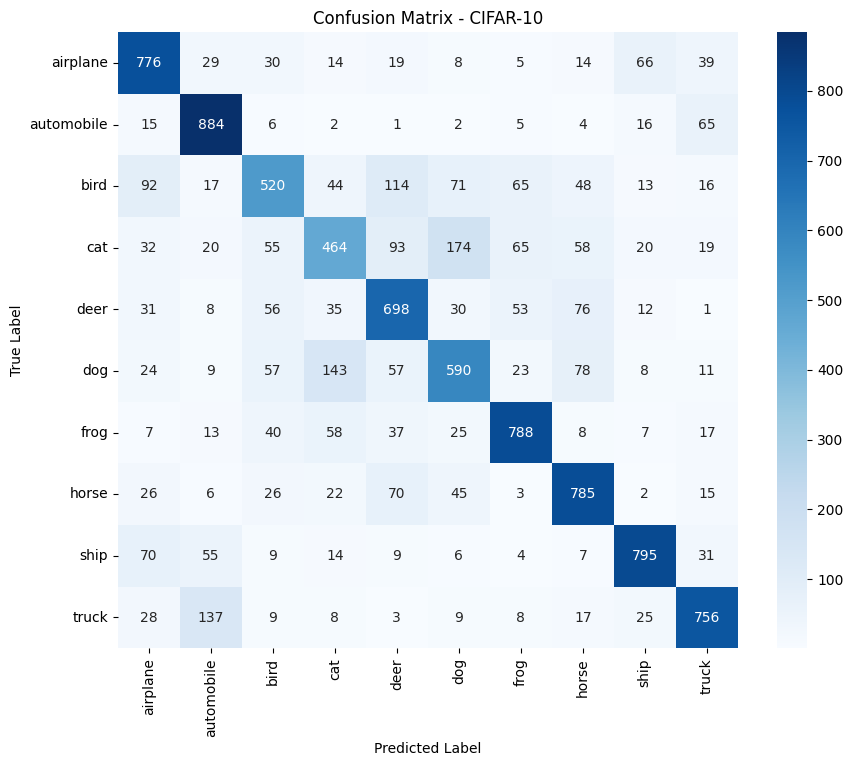

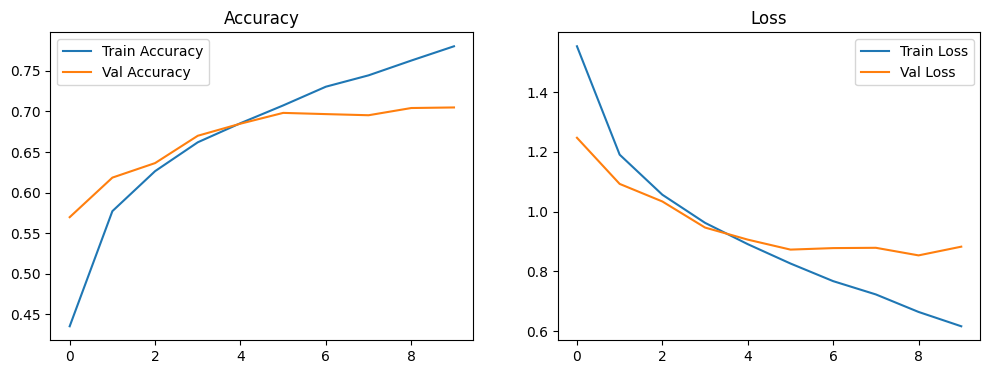

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# --- 1. LOAD DATA DIRECTLY FROM KERAS ---
# This requires NO folders and NO downloads. It just works.
print("Loading CIFAR-10 dataset...")
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# CIFAR-10 classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# --- 2. PREPROCESS ---
# Normalize pixel values to be between 0 and 1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Flatten y labels (CIFAR loads them as 2D arrays, we need 1D)
y_train = y_train.flatten()
y_test = y_test.flatten()

print(f"Training samples: {X_train.shape[0]}")
print(f"Image shape: {X_train.shape[1:]}") # Should be (32, 32, 3)

# --- 3. BUILD CNN ---
# Keeping the structure identical to your friend's MNIST code
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# --- 4. TRAIN ---
# Training for 10 epochs
history = model.fit(X_train, y_train, epochs=10,
                    batch_size=64, validation_split=0.2)

# --- 5. EVALUATE ---
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

# Predictions for Confusion Matrix
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# --- 6. VISUALIZE ---
# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - CIFAR-10')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Training Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()